In [1]:
import sys
sys.path.append("../src")
from data_loader import load_prices, load_returns, adf_test

import pandas as pd 
import numpy as np 
import matplotlib.pyplot as plt 
from statsmodels.regression.linear_model import OLS 
from statsmodels.tools import add_constant

prices = load_prices()
log_returns = load_returns()

valid_pairs = [("MA" , "V") , ("GS" , "MS")]
print("Data loaded. Valid pairs :" , valid_pairs)

Data loaded. Valid pairs : [('MA', 'V'), ('GS', 'MS')]


In [2]:
def  compute_hedge_ratio(prices , ticker1, ticker2):
    y= prices[ticker1]
    x = add_constant(prices[ticker2])
    model = OLS(y,x).fit()
    beta = model.params[ticker2]
    intercept = model.params["const"]
    r_squared = model.rsquared

    print("{ticker1} vs {ticker2}")
    print(f"  Beta(hedge ratio) : {beta:.4f}")
    print(f"  Intercept : {intercept:.4f}")
    print(f"  R_squared : {r_squared:.4f}")
    print()
    

    return beta , intercept

In [3]:
beta_MA_V , intercept_MA_V = compute_hedge_ratio(prices , "MA" , "V")
beta_GS_MS , intercept_GS_MS = compute_hedge_ratio(prices , "GS" , "MS")

{ticker1} vs {ticker2}
  Beta(hedge ratio) : 1.8669
  Intercept : -48.4810
  R_squared : 0.9830

{ticker1} vs {ticker2}
  Beta(hedge ratio) : 3.3518
  Intercept : 53.0735
  R_squared : 0.9628



In [4]:
def compute_spread (prices, ticker1 , ticker2, beta , intercept):
    spread = prices[ticker1] - beta * prices[ticker2] - intercept
    return spread

spread_MA_V = compute_spread(prices , "MA" , "V" ,  beta_MA_V , intercept_MA_V)
spread_GS_MS = compute_spread(prices , "GS" , "MS" , beta_GS_MS , intercept_GS_MS)

print("MA/V spread stats:")
print(f"  Mean : {spread_MA_V.mean():.4f}")
print(f"  Std  : {spread_MA_V.std():.4f}")
print(f"  Min  : {spread_MA_V.min():.4f}")
print(f"  Max  : {spread_MA_V.max():.4f}")
print()
print("GS/MS spread stats:")
print(f"  Mean : {spread_GS_MS.mean():.4f}")
print(f"  Std  : {spread_GS_MS.std():.4f}")
print(f"  Min  : {spread_GS_MS.min():.4f}")
print(f"  Max  : {spread_GS_MS.max():.4f}")

MA/V spread stats:
  Mean : 0.0000
  Std  : 9.0968
  Min  : -28.4685
  Max  : 28.2848

GS/MS spread stats:
  Mean : -0.0000
  Std  : 13.4661
  Min  : -40.6098
  Max  : 29.9789


In [5]:
print("ADF test on MA/V spread:")
adf_test(spread_MA_V , "MA/V Spread")

print("ADF test on GS/MS spread:")
adf_test(spread_GS_MS, "GS/MS spread")

ADF test on MA/V spread:
MA/V Spread
  ADF Statistic : -4.7409
  p-value       : 0.000070
  Critical (5%) : -2.8635
  Stationary    : True

ADF test on GS/MS spread:
GS/MS spread
  ADF Statistic : -3.6012
  p-value       : 0.005738
  Critical (5%) : -2.8635
  Stationary    : True



np.True_

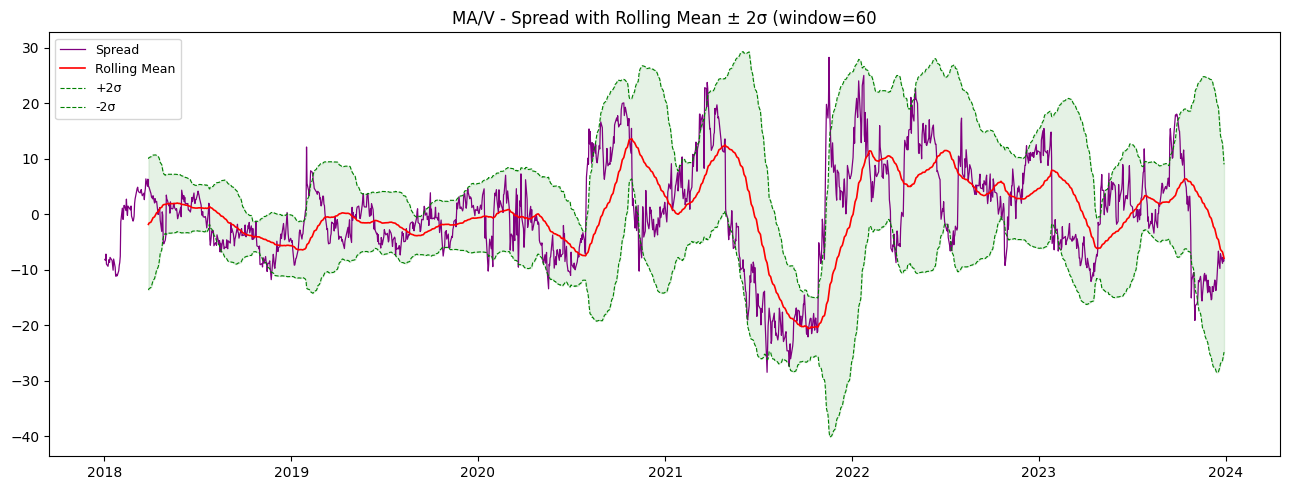

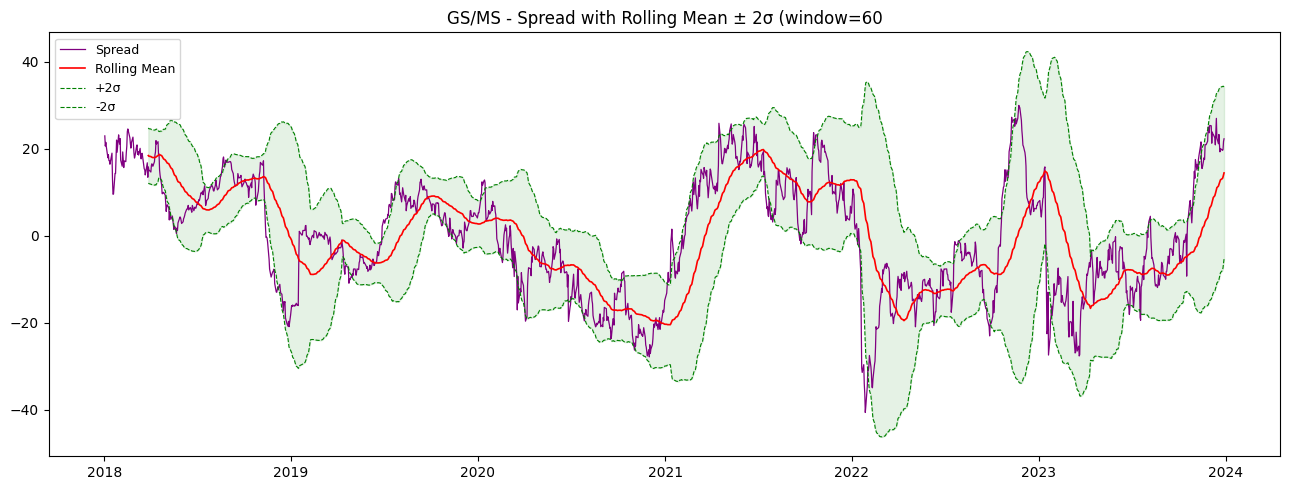

In [ ]:
# plot the spread with rolling mean and std


# Stock prices are noisy: A rolling mean smooths out the noise and reveals the underlying trend.
# A rolling mean (also called a moving average) is the average of the last N observations,
# # recalculated as you move through the data.

def plot_spread(spread, pair_name, window = 60):
    rolling_mean = spread.rolling(window).mean()
    rolling_std = spread.rolling(window).std()
    
    """ 
    Why Rolling Standard Deviation?
    The mean tells us:
    Where is the center?
    But it doesn't tell us:
    How much movement is normal?
    The standard deviation measures this variability.
    Small std:
    Values stay close to mean.
    Large std:
    Values jump around a lot.
    """

    # for how upper and lower are calculated , they are -2σ and +2σ , so chatgpt how the 2σ is calculated there is a formula

    upper = rolling_mean + 2 * rolling_std
    lower = rolling_mean - 2 * rolling_std

    fig,ax = plt.subplots(figsize = (13,5))

    ax.plot(spread.index , spread , color = "purple" , linewidth = 0.9 , label = "Spread")
    ax.plot(spread.index , rolling_mean , color = "red" , linewidth = 1.2 , label = "Rolling Mean")
    ax.plot(spread.index , upper , color="green" , linewidth = 0.8 , linestyle = "--" , label = "+2σ")
    ax.plot(spread.index , lower , color="green" , linewidth = 0.8 , linestyle = "--" , label = "-2σ")
    ax.fill_between(spread.index , upper , lower , alpha = 0.1 , color = "green")

    ax.set_title(f"{pair_name} - Spread with Rolling Mean ± 2σ (window={window}")
    ax.legend(fontsize = 9)
    plt.tight_layout()
    plt.savefig(f"../data/spread_{pair_name.replace('/','_')}.png" , dpi =120)
    plt.show()

plot_spread(spread_MA_V,"MA/V")
plot_spread(spread_GS_MS, "GS/MS")

In [7]:
spread = pd.DataFrame({
    "MA/V" : spread_MA_V,
    "GS/MS" : spread_GS_MS
})

spread.to_parquet("../data/spread.parquet")
verify = pd.read_parquet("../data/spread.parquet")
print(verify.shape)
print(verify.head(3))

(1509, 2)
                MA/V      GS/MS
Date                           
2018-01-02 -8.123314  22.982002
2018-01-03 -8.307735  20.641322
2018-01-04 -7.167098  21.492515


In [8]:
from data_loader import compute_hedge_ratio , compute_spread

beta, intercept = compute_hedge_ratio(prices,"MA" , "V")
spread = compute_spread(prices , "MA" , "V" , beta , intercept)
print(f"Beta:{beta:.4f} | Spread mean: {spread.mean():.4f}")

Beta:1.8669 | Spread mean: 0.0000
